# EXAMEN - Convocatoria 1 - Programación
Resolver el siguientes problemas de regresión lineal y clasificación.

## 1. Problema de Regresión lineal:

### Imports

In [1]:
import numpy as np
from math import sqrt
import pandas as pd

from IPython.display import display

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, r2_score, make_scorer
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

pd.set_option('display.max_colwidth', None) 

### 1.1. Generación de los datos:

Mediante la función `make_regressión` de sklearn, consultar su como emplearla para generar un conjunto de 2000 datos, 10 características, un ruido de 1 y fijar el parámetro ramdom_state=42.

In [2]:
X, y = make_regression(n_samples=2000, n_features=10, noise=1, random_state=42)
print(f"X: {X.shape}, Y: {y.shape}")

X: (2000, 10), Y: (2000,)


### 1.2. Partición de datos externa.
Realizar una partición externa de tipo hold-out seleccionando un 20% de los datos para test (fijar una semilla en 42).

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (1600, 10), X_test: (400, 10)


### 1.3. Estandarización de los datos de train y test.
Utilizar el método StandardScaler().

In [4]:
std_scaling = StandardScaler()

X_train_scaled = std_scaling.fit_transform(X_train)
X_test_scaled = std_scaling.transform(X_test)

print(f"Media de X_train_scaled : {X_train_scaled[:, 0].mean():.4f}")
print(f"Desviación estándar de X_train_scaled: {X_train_scaled[:, 0].std():.4f}")

Media de X_train_scaled : 0.0000
Desviación estándar de X_train_scaled: 1.0000


### 1.4. Creación de modelos e hiperparametrización mediante el método de sklearn GridSearchCV:

Instrucciones:

- Cree los siguientes modelos de regresión en un diccionario:
  - Regresión Lineal (OLS).
  - Regresión Lasso
  - Regresión Rígida
  - Vecinos más cercanos (KNN)

- Cree las siguiente métricas en un diccionario para evaluar:
  - MAE
  - MSE
  - RMSE
  - R2

- Haga una búsqueda de los siguientes hiperparámetros mediante GridSearchCV:

```
# Hiperparametros
parameters = {'OLS':{},
              'Lasso':{'alpha':(0.1,0.5,1,5,10,50,100)},
              'Ridge':{'alpha':(0.1,0.5,1,5,10,50,100)},
              'KNN':{'n_neighbors':np.arange(1,15),
                     'weights':('uniform','distance'),
                     'metric':('euclidean','manhattan','cosine')
                     }
              }
```

In [5]:
# Algoritmos
algorithms = {
    'OLS': LinearRegression(),
    'Lasso': Lasso(),
    'Ridge': Ridge(),
    'KNN': KNeighborsRegressor()
}

# Metricas
metrics = {
    'MAE': make_scorer(mean_absolute_error, greater_is_better=False),
    'MSE': make_scorer(mean_squared_error, greater_is_better=False),
    'RMSE':make_scorer(lambda y, y_pred:
                      sqrt(mean_squared_error(y, y_pred)),
                      greater_is_better=False),
    'R2': make_scorer(r2_score)}

# Hiperparametros
parameters = {'OLS':{},
              'Lasso':{'alpha':(0.1,0.5,1,5,10,50,100)},
              'Ridge':{'alpha':(0.1,0.5,1,5,10,50,100)},
              'KNN':{'n_neighbors':np.arange(1,15),
                     'weights':('uniform','distance'),
                     'metric':('euclidean','manhattan','cosine')
                     }
              }

### 1.5. Evaluación de los modelos sobre el conjunto de test.
- Entrenar los modelos anteriores utilizando todos los datos de entrenamiento y quédese con el mejor modelo de cada uno de los modelos de regresión arrojados por GridSearchCV. Es decir, debe tener un mejor modelo por cada regresión (OLS, Lasso, Rígida y KNN)
- Evaluar su rendimiento sobre el conjunto de test mostrando para cada uno de los modelos

In [6]:
models_grid_search = {}

for name, _ in algorithms.items():
    print(10*'*', 'Algoritmo '+name, 10*'*')
    model_cv = GridSearchCV(algorithms[name], parameters[name], scoring=metrics, refit="RMSE", cv=5, return_train_score=True)
    models_grid_search[name] = model_cv.fit(X_train_scaled, y_train)
    
    cv_res = models_grid_search[name].cv_results_
    print("Mejores parametros:", models_grid_search[name].best_params_)
    
    best_iter = models_grid_search[name].best_index_
    print('Metricas para el mejor best index:')
    for metric in metrics:
        train_score = cv_res['mean_train_'+metric][best_iter]
        test_score = cv_res['mean_test_'+metric][best_iter]
        test_std = cv_res['std_test_'+metric][best_iter]
        print(f'{metric}:')
        print(f' -> Train: {train_score:.4f}')
        print(f' -> Test:  {test_score:.4f} (std: {test_std:.4f})')


********** Algoritmo OLS **********
Mejores parametros: {}
Metricas para el mejor best index:
MAE:
 -> Train: -0.8070
 -> Test:  -0.8143 (std: 0.0316)
MSE:
 -> Train: -1.0013
 -> Test:  -1.0201 (std: 0.0851)
RMSE:
 -> Train: -1.0006
 -> Test:  -1.0091 (std: 0.0415)
R2:
 -> Train: 1.0000
 -> Test:  1.0000 (std: 0.0000)
********** Algoritmo Lasso **********
Mejores parametros: {'alpha': 0.1}
Metricas para el mejor best index:
MAE:
 -> Train: -0.8511
 -> Test:  -0.8599 (std: 0.0377)
MSE:
 -> Train: -1.1017
 -> Test:  -1.1243 (std: 0.1074)
RMSE:
 -> Train: -1.0496
 -> Test:  -1.0592 (std: 0.0497)
R2:
 -> Train: 1.0000
 -> Test:  1.0000 (std: 0.0000)
********** Algoritmo Ridge **********
Mejores parametros: {'alpha': 0.1}
Metricas para el mejor best index:
MAE:
 -> Train: -0.8075
 -> Test:  -0.8148 (std: 0.0319)
MSE:
 -> Train: -1.0016
 -> Test:  -1.0204 (std: 0.0862)
RMSE:
 -> Train: -1.0007
 -> Test:  -1.0093 (std: 0.0420)
R2:
 -> Train: 1.0000
 -> Test:  1.0000 (std: 0.0000)
********** A

,Modelo,MAE,MSE,RMSE,R2
0,OLS,0.7731,0.9534,0.9764,1.0000
1,Lasso,0.8031,1.0349,1.0173,1.0000
2,Ridge,0.7727,0.9524,0.9759,1.0000
3,KNN,50.0401,4579.8916,67.6749,0.8720


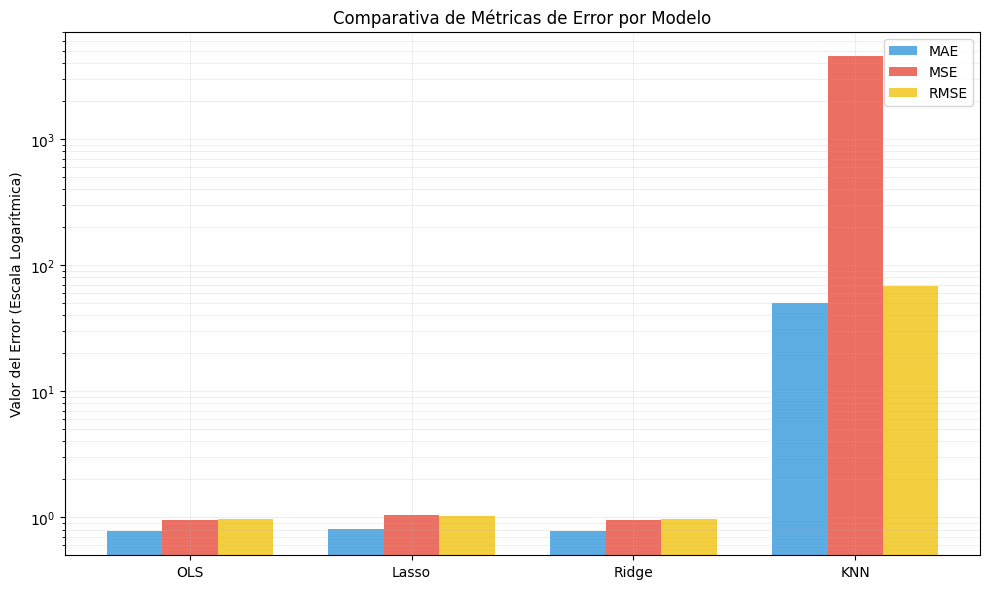

In [7]:
result_test = []

for name, model_grid_search in models_grid_search.items():
    result_test_as_dict = {}
    result_test_as_dict['Modelo'] = name
    model = model_grid_search.best_estimator_
    for metric_name, metric in metrics.items():
        score = metric(model, X_test_scaled, y_test)
        result_test_as_dict[metric_name] = f'{abs(score):.4f}'
    result_test.append(result_test_as_dict)

display(pd.DataFrame(result_test))

# -- Grafica
import matplotlib.pyplot as plt

modelos = [r['Modelo'] for r in result_test]
mae = [float(r['MAE']) for r in result_test]
mse = [float(r['MSE']) for r in result_test]
rmse = [float(r['RMSE']) for r in result_test]

n_modelos_reg = np.arange(len(modelos))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(n_modelos_reg - width, mae, width, label='MAE', color='#3498db', alpha=0.8)
ax.bar(n_modelos_reg, mse, width, label='MSE', color='#e74c3c', alpha=0.8)
ax.bar(n_modelos_reg + width, rmse, width, label='RMSE', color='#f1c40f', alpha=0.8)

ax.set_yscale('log')

ax.set_ylabel('Valor del Error (Escala Logarítmica)')
ax.set_title('Comparativa de Métricas de Error por Modelo')
ax.set_xticks(n_modelos_reg)
ax.set_xticklabels(modelos)
ax.legend()
ax.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.show()

### 1.6. Interpretación de resultados.
* Justifica cuál de los modelos utilizarías para ponerlo en producción

El modelo que utilizaría es el **Ridge**, debido a que presenta el error más bajo (RMSE: 0.9759) y un ajuste perfecto (R2: 1.00), superando significativamente la inestabilidad de KNN que presenta sobreajuste, ya que, tiene un error cero en las métricas de Train pero errores altos en las de Test. A diferencia de OLS, Ridge ofrece mayor generalización mediante la regularización L2, controlando la complejidad del modelo sin sacrificar precisión. Aunque Lasso también regulariza, sus errores son ligeramente superiores a los de Ridge, lo que indica que la penalización L2 (Ridge) se adapta mejor. Para finalizar, es importante mencionar que la mínima diferencia entre las métricas de Train y Test confirma la ausencia de sobreajuste, consolidándolo como el modelo más robusto y eficiente.

## 2. Problema de Clasificación con generación de datos sintéticos y selección de características

En esta actividad se trabajará con generación de datos sintéticos para problemas de clasificación utilizando la función `make_classification` de la librería **scikit-learn**.

El objetivo es evaluar si distintos métodos de selección de características y modelos de clasificación son capaces de identificar las variables realmente relevantes dentro de un conjunto de datos generado artificialmente.

### 2.1 Importación de librerías

Importe las siguientes librerías:

In [8]:
import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_colwidth', None) 

### 2.2. Generación del conjunto de datos

2.2.1. Utilice `make_classification` para generar un dataset de clasificación binaria.

Debe definir explícitamente los siguientes parámetros:

- `n_samples`
- `n_features`
- `n_informative`
- `n_redundant`

El dataset debe tener:

- al menos **500 observaciones**
- al menos **10 características**

El objetivo es que existan variables:

- **informativas**
- **redundantes**
- **no informativas**

2.2.2. Explique brevemente los valores elegidos para cada parámetro.


In [9]:
# Dado que uso (shuffle=False) se pueden inferir los índices basados en la posición fija 
n_inf = 5
n_red = 3

X_classif, y_classif = make_classification(n_samples=1600, n_features=12, n_informative=n_inf, n_redundant=n_red, shuffle=False, random_state=42)
print(f"X: {X_classif.shape}, Y: {y_classif.shape}")

indices_informativas = list(range(n_inf))
indices_redundantes = list(range(n_inf, n_inf + n_red))
indices_ruido = list(range(n_inf + n_red, 12)) # El resto hasta 12

print(f"Índices Informativas (n_informative): {indices_informativas}")
print(f"Índices Redundantes (n_redundant):   {indices_redundantes}")
print(f"Índices de Ruido (restantes):        {indices_ruido}")

X: (1600, 12), Y: (1600,)
Índices Informativas (n_informative): [0, 1, 2, 3, 4]
Índices Redundantes (n_redundant):   [5, 6, 7]
Índices de Ruido (restantes):        [8, 9, 10, 11]


A continuación describo la explicación de los valores elegidos para cada parámetro:

- **n_samples:** Se eligen 1600 observaciones para asegurar un dataset robusto que facilite el entrenamiento del modelo de clasificación.
- **n_features:** Se definen 12 características totales para permitir una mezcla equilibrada entre variables útiles, redundantes y ruido aleatorio.
- **n_informative:** Se definen 5 variables informativas para establecer una estructura clara, obligando al modelo de clasificación a identificar los patrones reales de separación entre clases a partir de las características esenciales, incluso en presencia de ruido.
- **n_redundant:** Se incluyen 3 variables para introducir multicolinealidad mediante combinaciones lineales, evaluando así la capacidad del modelo para gestionar información duplicada.

### 2.3. División de los datos.

Divida el dataset en:

- **conjunto de entrenamiento**
- **conjunto de prueba**

El conjunto de entrenamiento se utilizará para:

- selección de características
- búsqueda de hiperparámetros
- entrenamiento de los modelos

El conjunto de prueba se utilizará **únicamente para evaluar el desempeño final de los modelos**.

In [10]:
X_classif_train, X_classif_test, y_classif_train, y_classif_test = train_test_split(X_classif, y_classif, test_size=0.2, random_state=42)
print(f"X_train: {X_classif_train.shape}, X_test: {X_classif_test.shape}")

X_train: (1280, 12), X_test: (320, 12)


### 2.4. Selección de caractarística

Aplique un método de selección de características para identificar cuáles variables parecen ser más relevantes para la predicción.

Puede utilizar el método **SelectKBest** de `sklearn.feature_selection`. Este método evalúa cada característica de forma individual mediante una medida estadística y selecciona las **k variables con mayor puntuación**, es decir, aquellas que tienen mayor relación con la variable objetivo.

Utilice como función de puntuación `f_classif`.

Compare las características seleccionadas con las definidas como **informativas** en `make_classification` y discuta si el método logra identificarlas correctamente.

In [11]:
selector = SelectKBest(f_classif, k=5)
selector.fit(X_classif_train, y_classif_train)

indices_seleccionados = selector.get_support(indices=True)

X_classif_train_selected = selector.transform(X_classif_train)
X_classif_test_selected = selector.transform(X_classif_test)
print(X_classif_train_selected.shape)
print(X_classif_test_selected.shape)

indices_esperados = list(range(5))
print(f"Índices elegidos: {indices_seleccionados}")
print(f"Índices esperados: {indices_esperados}")

(1280, 5)
(320, 5)
Índices elegidos: [1 4 5 6 7]
Índices esperados: [0, 1, 2, 3, 4]


Al observar los índices elegidos por el selector (1, 4, 5, 6, 7), se observa que el algoritmo identificó correctamente 2 de las 5 variables informativas (1 y 4). Sin embargo, las 3 posiciones restantes fueron ocupadas por la totalidad de las variables redundantes (5, 6 y 7), desplazando a las informativas 0, 2 y 3. Este fenómeno demuestra que, para el criterio estadístico de SelectKBest, las variables redundantes presentan una correlación más fuerte o linealmente clara con la clase que algunas de las variables informativas originales.

Veamos el p-values o scores de SelectKBest, lo que nos permitirá ver qué tan cerca estuvieron las otras caracteristicas de ser seleccionadas:

In [12]:
df_analisis = pd.DataFrame({
    'Índice': range(12),
    'Tipo Original': ['Informativa']*5 + ['Redundante']*3 + ['Ruido']*4,
    'Score': selector.scores_,
    'P-Value': selector.pvalues_
})

display(df_analisis.sort_values(by='Score', ascending=False))

,Índice,Tipo Original,Score,P-Value
6,6,Redundante,388.229501,1.118070e-75
7,7,Redundante,283.714947,1.199833e-57
4,4,Informativa,172.478329,4.742743e-37
5,5,Redundante,148.832562,1.842561e-32
1,1,Informativa,142.055309,3.941553e-31
3,3,Informativa,116.726025,4.250275e-26
0,0,Informativa,93.629997,2.021975e-21
11,11,Ruido,0.928444,3.354500e-01
9,9,Ruido,0.293792,5.878953e-01
2,2,Informativa,0.188590,6.641657e-01


La característica informativa (2) y las de ruido (11, 9, 8, 10) presentaron puntajes que no son estadísticamente significativos (scores inferiores a 1). Por el contrario, la alta significancia de las redundantes (6, 7, 5) demuestra que estas pueden presentar una estructura lineal más evidente que las variables teóricamente esenciales (como la 2), desplazándolas en el proceso de selección y exigiendo métodos de evaluación más robustos.

## 2.5. Escalado de datos

Antes de entrenar los modelos, estandarice las variables utilizando **StandardScaler** de `sklearn.preprocessing`.

La estandarización consiste en transformar las variables para que tengan:

- media igual a 0
- desviación estándar igual a 1

Este paso es importante para modelos sensibles a la escala de los datos, como **regresión logística** y **SVM**. Los árboles de decisiones, son independientes del escalado.

El escalado debe realizarse de la siguiente manera:

1. Ajustar el `StandardScaler` **únicamente con el conjunto de entrenamiento**.
2. Aplicar esa transformación tanto al conjunto de entrenamiento como al conjunto de prueba.


In [13]:
std_scaling = StandardScaler()

X_classif_train_scaled = std_scaling.fit_transform(X_classif_train)
X_classif_test_scaled = std_scaling.transform(X_classif_test)
print('X_classif_train_scaled', X_classif_train_scaled.shape)
print('X_classif_test_scaled', X_classif_test_scaled.shape)

X_classif_train_selected_scaled = std_scaling.fit_transform(X_classif_train_selected)
X_classif_test_selected_scaled = std_scaling.transform(X_classif_test_selected)
print('X_classif_train_selected_scaled', X_classif_train_selected_scaled.shape)
print('X_classif_test_selected_scaled', X_classif_test_selected_scaled.shape)

X_classif_train_scaled (1280, 12)
X_classif_test_scaled (320, 12)
X_classif_train_selected_scaled (1280, 5)
X_classif_test_selected_scaled (320, 5)


### 2.6. Modelos e hiperparametrización

Trabaje con los siguientes modelos.

**Modelos obligatorios**

- Árbol de decisión (`DecisionTreeClassifier`)
- Regresión logística (`LogisticRegression`)

**Modelo bonus**

- Máquina de soporte vectorial (`SVC`)

Para cada modelo, realice una búsqueda de hiperparámetros utilizando **GridSearchCV** sobre el **conjunto de entrenamiento**.

Utilice las siguientes listas de hiperparámetros:

**Árbol de decisión**

- `max_depth`: [3, 5, 10, None]
- `min_samples_split`: [2, 5, 10]
- `criterion`: ["gini", "entropy"]

**Regresión logística**

- `C`: [0.01, 0.1, 1, 10]
- `solver`: ["lbfgs", "liblinear"]

**SVM (bonus)**

- `C`: [0.1, 1, 10]
- `kernel`: ["linear", "rbf"]
- `gamma`: ["scale", "auto"]

Utilice validación cruzada dentro de `GridSearchCV` para determinar la mejor combinación de hiperparámetros.


In [14]:
# Algoritmos
algorithms_classif = {
    'DecisionTree': DecisionTreeClassifier(),
    'Logr': LogisticRegression(),
    'SVC': SVC()
}

# Hiperparametros
parameters_classif = {
    'DecisionTree':{
        'max_depth':(3, 5, 10, None),
        'min_samples_split':(2, 5, 10),
        'criterion':("gini", "entropy")
    },
    'Logr':{
        'C':(0.01, 0.1, 1, 10),
        'solver':("lbfgs", "liblinear")
    },
    'SVC':{'C':(0.1, 1, 10),
           'kernel':("linear", "rbf"),
           'gamma':("scale", "auto")
          }
}

In [15]:
models_classif_grid_search = {}
grid_search_classif_results = []

for name, _ in algorithms_classif.items():
    grid_search_classif_result = {}
    grid_search_classif_result['Modelo'] = name
    
    model_classif_cv = GridSearchCV(algorithms_classif[name], parameters_classif[name], scoring='accuracy', cv=5, return_train_score=True)
    models_classif_grid_search[name] = model_classif_cv.fit(X_classif_train_selected_scaled, y_classif_train)
    
    cv_res = models_classif_grid_search[name].cv_results_
    grid_search_classif_result['Mejores parametros'] = models_classif_grid_search[name].best_params_
    
    best_iter = models_classif_grid_search[name].best_index_
    train_score = cv_res['mean_train_score'][best_iter]
    test_score = cv_res['mean_test_score'][best_iter]
    test_std = cv_res['std_test_score'][best_iter]
    
    grid_search_classif_result['Accuracy Train'] = f'{train_score:.4f}'
    grid_search_classif_result['Accuracy Test'] = f'{test_score:.4f} (std: {test_std:.4f})'
    grid_search_classif_results.append(grid_search_classif_result)

display(pd.DataFrame(grid_search_classif_results))

,Modelo,Mejores parametros,Accuracy Train,Accuracy Test
0,DecisionTree,"{'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 5}",0.9467,0.8352 (std: 0.0161)
1,Logr,"{'C': 10, 'solver': 'lbfgs'}",0.8039,0.8039 (std: 0.0127)
2,SVC,"{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}",0.9088,0.8977 (std: 0.0117)


### 2.7. Evaluación y análisis

Para cada modelo:

- Del punto anterior, obtenga el modelo con **los mejores hiperparámetros**.
- Evalúe el modelo final en el **conjunto de prueba**.
- Realice este proceso en dos escenarios:
  - utilizando **todas las características**
  - utilizando **solo las características seleccionadas**
- Compare los resultados utilizando métricas de clasificación apropiada y discuta:
  - si la selección de características mejora el desempeño del modelo
  - si reduce la complejidad del modelo
  - si permite identificar correctamente las variables informativas generadas en el dataset
  - qué modelo obtiene mejor desempeño después del ajuste de hiperparámetros


,Modelo,Accuracy con 5 variables (Selector),Accuracy con 12 variables (Completo),Diferencia de rendimiento
0,DecisionTree,0.8156,0.8812,0.0656
1,Logr,0.8344,0.8469,0.0125
2,SVC,0.9219,0.9344,0.0125


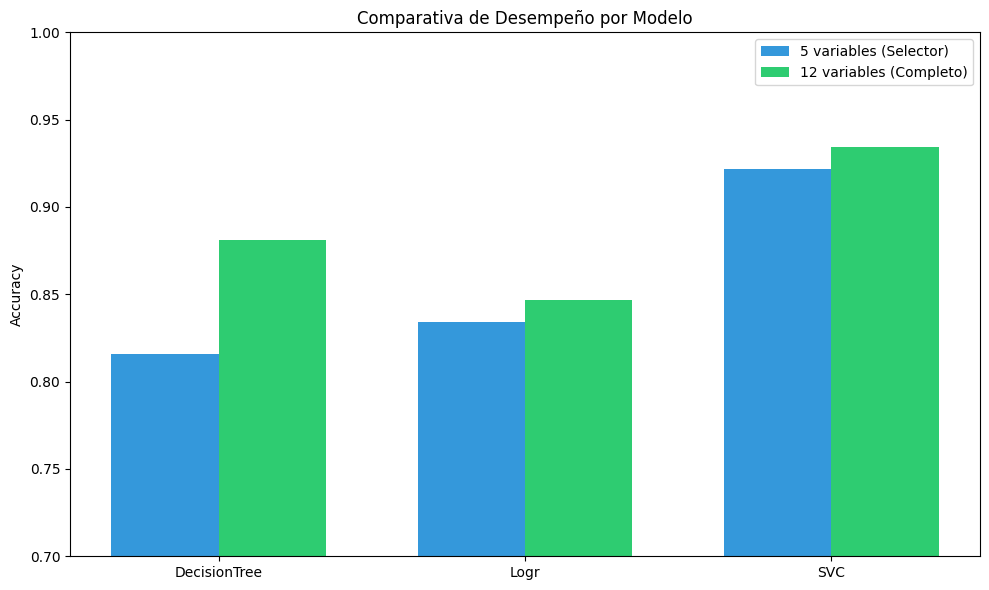

In [16]:
from sklearn.base import clone

accuracy_classif_results = []

for name, model_grid_search in models_classif_grid_search.items():
    accuracy_classif_result = {}
    accuracy_classif_result['Modelo'] = name
    
    modelo_5_vars = model_grid_search.best_estimator_
    modelo_todas_vars = clone(modelo_5_vars)
    modelo_todas_vars.fit(X_classif_train_scaled, y_classif_train)

    y_pred_5 = modelo_5_vars.predict(X_classif_test_selected_scaled)
    y_pred_12 = modelo_todas_vars.predict(X_classif_test_scaled)
    
    acc_5 = accuracy_score(y_classif_test, y_pred_5)
    acc_12 = accuracy_score(y_classif_test, y_pred_12)

    accuracy_classif_result['Accuracy con 5 variables (Selector)'] = f'{acc_5:.4f}'
    accuracy_classif_result['Accuracy con 12 variables (Completo)'] = f'{acc_12:.4f}'
    accuracy_classif_result['Diferencia de rendimiento'] = f'{abs(acc_5 - acc_12):.4f}'
    accuracy_classif_results.append(accuracy_classif_result)

display(pd.DataFrame(accuracy_classif_results))

# -- Grafica
import matplotlib.pyplot as plt

nombres_modelos = [res['Modelo'] for res in accuracy_classif_results]
acc_5_vals = [float(res['Accuracy con 5 variables (Selector)']) for res in accuracy_classif_results]
acc_12_vals = [float(res['Accuracy con 12 variables (Completo)']) for res in accuracy_classif_results]

n_modelos = np.arange(len(nombres_modelos))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(n_modelos - width/2, acc_5_vals, width, label='5 variables (Selector)', color='#3498db')
ax.bar(n_modelos + width/2, acc_12_vals, width, label='12 variables (Completo)', color='#2ecc71')

ax.set_ylabel('Accuracy')
ax.set_title('Comparativa de Desempeño por Modelo')
ax.set_xticks(n_modelos)
ax.set_xticklabels(nombres_modelos)
ax.set_ylim(0.7, 1.0)
ax.legend()

plt.tight_layout()
plt.show()

Con base en los anteriores resultados, se puede decir que:

**¿La selección de características mejora el desempeño del modelo?**
No necesariamente. En DecisionTree, Logr y Svc, el desempeño disminuyó al usar solo 5 variables. Esto sugiere que el selector (SelectKBest), al ser un método lineal, descartó variables que estos modelos sí lograban aprovechar para mejorar su precisión.

**¿Reduce la complejidad del modelo?**
Sí, significativamente. Al pasar de 12 a 5 variables, reduces la dimensionalidad del espacio de entrada en un 58%. Esto implica modelos más rápidos de entrenar, menor consumo de memoria y ayuda a la interpretabilidad, ya que, es más fácil explicar un modelo de 5 variables que uno de 12.

**¿Permite identificar correctamente las variables informativas generadas?**
El selector identificó las variables con mayor fuerza estadística, pero estas no coincidieron exactamente con las n_informative teóricas, prefiriendo las redundantes (6, 7, 5) por su claridad lineal. La caída del porcentaje en el Árbol de Decisión ratifica que el selector no logró capturar toda la estructura informativa latente del dataset.

**¿Qué modelo obtiene mejor desempeño después del ajuste?**
El modelo con mejor desempeño es SVC, alcanzando un 0.9344 con las características completas y manteniendo un sólido 0.9219 con la selección de características. Es el algoritmo que mejor equilibra la complejidad y el poder predictivo en este ejercicio.
